In [1]:
%matplotlib inline
import os
import sys
import json
from pathlib import Path
from urllib.parse import quote_plus

import numpy as np
import pandas as pd

_PATH = Path.cwd()
_PROJECT_ROOT = _PATH
for _ in range(5):
    if (_PROJECT_ROOT / ".env").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

sys.path.insert(0, str(_PROJECT_ROOT / "Models" / "Training"))
from dotenv import load_dotenv
from sqlalchemy import create_engine
load_dotenv(_PROJECT_ROOT / ".env")

def get_engine():
    host = os.getenv("PGHOST", "localhost")
    port = os.getenv("PGPORT", "5432")
    user = os.getenv("PGUSER", "postgres")
    password = os.getenv("PGPASSWORD", "")
    dbname = os.getenv("PGDATABASE", "baseball")
    pw = quote_plus(password) if password else ""
    return create_engine(f"postgresql://{user}:{pw}@{host}:{port}/{dbname}")

from data_prep_batters import EVENTS_TO_IN_PLAY_RESULT
from physics_engine import compute_trajectory
engine = get_engine()
print("Setup OK.")

Setup OK.


In [2]:
# Sample of batted balls (same feature construction as training: 4-class + ISO + zone × stand)
q = """
SELECT launch_speed, launch_angle, events, plate_x, plate_z, stand, career_BA, career_SLG,
       home_team, release_spin_rate
FROM clean_statcast_with_batter
WHERE launch_speed IS NOT NULL AND launch_angle IS NOT NULL
ORDER BY RANDOM()
LIMIT 25000
"""
df = pd.read_sql(q, engine)
df["events_clean"] = df["events"].astype(str).str.strip().str.lower()
df["in_play_raw"] = df["events_clean"].map(EVENTS_TO_IN_PLAY_RESULT)
# Map to 4-class (2B+3B -> extra_base_hit) to match trained model
df["in_play_result"] = df["in_play_raw"].map(lambda x: "extra_base_hit" if x in ("in_play_2b", "in_play_3b") else x)
df = df.dropna(subset=["in_play_result"]).copy()
def _physics_distance(row):
    ps = row.get("release_spin_rate")
    try:
        psf = float(ps) if ps is not None and pd.notna(ps) else None
    except (TypeError, ValueError):
        psf = None
    ht = row.get("home_team")
    hts = str(ht).strip().upper() if ht is not None and pd.notna(ht) and str(ht).strip() else None
    if hts in ("NAN", "NONE", ""):
        hts = None
    traj = compute_trajectory(
        float(row["launch_speed"]), float(row["launch_angle"]), 0.0,
        use_drag=True,
        pitch_spin_rpm=psf,
        home_team=hts,
    )
    return traj["distance_ft"]

df["distance_ft"] = df.apply(_physics_distance, axis=1)
# PostgreSQL may return lowercase column names (career_ba, career_slg)
career_slg = df["career_slg"] if "career_slg" in df.columns else df["career_SLG"]
career_ba = df["career_ba"] if "career_ba" in df.columns else df["career_BA"]
df["career_iso"] = (career_slg.astype(float) - career_ba.astype(float)).clip(lower=0)
df.loc[career_ba.isna() | career_slg.isna(), "career_iso"] = np.nan
df["career_iso"] = df["career_iso"].fillna(0.12)
df["stand_L"] = (df["stand"].astype(str).str.upper().str.strip() == "L").astype(int)
df["plate_x_stand"] = df["plate_x"].astype(float) * (2 * df["stand_L"] - 1)
df["plate_z_stand"] = df["plate_z"].astype(float) * (2 * df["stand_L"] - 1)
print(f"Sample size: {len(df)}. Outcome counts (4-class):\n{df['in_play_result'].value_counts().sort_index()}")

Sample size: 12661. Outcome counts (4-class):
in_play_result
extra_base_hit     861
in_play_1b        2728
in_play_hr         611
in_play_out       8461
Name: count, dtype: int64


In [3]:
# Load final outcome model and metadata (single or two-stage)
import joblib
_SAVED = _PROJECT_ROOT / "Models" / "Training" / "saved_models"
if not (_SAVED / "final_outcome_metadata.json").exists():
    _SAVED = _PROJECT_ROOT / "Models" / "saved_models"
with open(_SAVED / "final_outcome_metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_cols"]
CLASS_NAMES = meta["class_names"]
two_stage = meta.get("two_stage", False)
if two_stage:
    stage1 = joblib.load(_SAVED / "final_outcome_stage1_model.joblib")
    stage2 = joblib.load(_SAVED / "final_outcome_stage2_model.joblib")
    model = None
else:
    model = joblib.load(_SAVED / "final_outcome_model.joblib")
    stage1 = stage2 = None
HR_DIST, HR_ANGLE_LO, HR_ANGLE_HI = meta.get("hr_rule_distance_ft", 380), meta.get("hr_rule_launch_angle_min", 20), meta.get("hr_rule_launch_angle_max", 40)
hr_idx = CLASS_NAMES.index("in_play_hr") if "in_play_hr" in CLASS_NAMES else None
# Load HR suppress multiplier from metadata
hr_suppress_multiplier = meta.get("hr_suppress_multiplier", 0.8)
print(f"Loaded {'two-stage' if two_stage else 'single'} model. feature_cols={feature_cols}, classes={CLASS_NAMES}")
if two_stage:
    print(f"HR suppress multiplier from metadata: {hr_suppress_multiplier} (applied to Stage 2 probs in next cell)")

Loaded two-stage model. feature_cols=['launch_speed', 'launch_angle', 'distance_ft', 'career_iso', 'plate_x', 'plate_z', 'stand_L', 'plate_x_stand', 'plate_z_stand'], classes=['in_play_out', 'in_play_1b', 'extra_base_hit', 'in_play_hr']
HR suppress multiplier from metadata: 0.8 (applied to Stage 2 probs in next cell)


In [4]:
# Predict: use raw probabilities + explicit HR multiplier, that ignores metadata if you use .predict()
X = df[feature_cols].astype(float).reindex(columns=feature_cols, fill_value=0)
if two_stage:
    bin_pred = stage1.predict(X)
    pred_idx = np.zeros(len(df), dtype=int)
    hit_mask = (bin_pred == 1)
    pred_idx[~hit_mask] = 0
    if hit_mask.any():
        # 1. Get RAW probabilities from Stage 2
        X_hit = X.loc[hit_mask]
        stage2_probs = stage2.predict_proba(X_hit)
        # 2. Stage 2 class order: 0=in_play_1b, 1=extra_base_hit, 2=in_play_hr
        STAGE2_HIT_NAMES = ["in_play_1b", "extra_base_hit", "in_play_hr"]
        hr_col_idx = STAGE2_HIT_NAMES.index("in_play_hr")  # 2
        # 3. Apply the phantom multiplier from metadata
        stage2_probs = stage2_probs.copy()
        stage2_probs[:, hr_col_idx] *= hr_suppress_multiplier
        # 4. Renormalize so each row sums to 1.0
        stage2_probs = stage2_probs / stage2_probs.sum(axis=1, keepdims=True)
        # 5. Take adjusted predictions (use these for graph and confusion matrix)
        adjusted_hit_preds = np.argmax(stage2_probs, axis=1)
        pred_idx[hit_mask] = 1 + adjusted_hit_preds
else:
    pred_idx = model.predict(X)
# HR rule override (CRITICAL FIX: Only apply to hits, do not override flyouts!)
if hr_idx is not None:
    hr_rule = (df["distance_ft"].values >= HR_DIST) & (df["launch_angle"].values >= HR_ANGLE_LO) & (df["launch_angle"].values <= HR_ANGLE_HI)
    out_idx = CLASS_NAMES.index("in_play_out") if "in_play_out" in CLASS_NAMES else 0
    pred_idx = np.where(hr_rule & (pred_idx != out_idx), hr_idx, pred_idx)
y_true = df["in_play_result"].map(lambda x: CLASS_NAMES.index(x) if x in CLASS_NAMES else 0).values
y_pred_names = [CLASS_NAMES[i] for i in pred_idx]
df["predicted"] = y_pred_names

In [5]:
# Metrics: accuracy, macro F1, confusion matrix, actual vs predicted distribution
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

acc = accuracy_score(df["in_play_result"], df["predicted"])
macro_f1 = f1_score(df["in_play_result"], df["predicted"], average="macro", labels=CLASS_NAMES, zero_division=0)
print(f"Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}")
print("\nClassification report:")
print(classification_report(df["in_play_result"], df["predicted"], labels=CLASS_NAMES, zero_division=0))
print("Confusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(df["in_play_result"], df["predicted"], labels=CLASS_NAMES))

Accuracy: 0.7827, Macro F1: 0.6159

Classification report:
                precision    recall  f1-score   support

   in_play_out       0.84      0.90      0.87      8461
    in_play_1b       0.67      0.59      0.63      2728
extra_base_hit       0.42      0.19      0.26       861
    in_play_hr       0.63      0.78      0.70       611

      accuracy                           0.78     12661
     macro avg       0.64      0.62      0.62     12661
  weighted avg       0.77      0.78      0.77     12661

Confusion matrix (rows=actual, cols=predicted):
[[7646  565  118  132]
 [ 993 1622   99   14]
 [ 316  251  165  129]
 [ 126    0    8  477]]


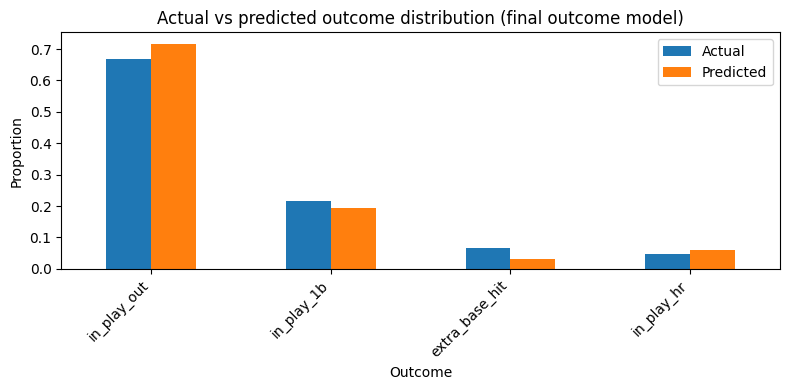

In [6]:
# Actual vs predicted outcome distribution (like batter 5-outcome chart)
import matplotlib.pyplot as plt
actual_props = df["in_play_result"].value_counts(normalize=True).reindex(CLASS_NAMES, fill_value=0)
pred_props = df["predicted"].value_counts(normalize=True).reindex(CLASS_NAMES, fill_value=0)
dist_df = pd.DataFrame({"Actual": actual_props, "Predicted": pred_props})
dist_df.plot(kind="bar", figsize=(8, 4))
plt.xlabel("Outcome")
plt.ylabel("Proportion")
plt.title("Actual vs predicted outcome distribution (final outcome model)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()